In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import time

In [9]:
def inicializar_ambiente(linhas, colunas, quantidade_itens):
    grid = np.zeros((linhas, colunas), dtype=int)
    total_celulas = linhas * colunas
    
    if quantidade_itens > total_celulas:
        raise ValueError("Quantidade de itens maior que o número de células")

    # Escolhe índices únicos
    indices = np.random.choice(
        total_celulas, 
        size=quantidade_itens, 
        replace=False
    )

    # Converte para 2D
    linhas_idx, colunas_idx = np.unravel_index(indices, (linhas, colunas))

    grid[linhas_idx, colunas_idx] = 1

    return grid

In [10]:
def visualizar_ambiente(grid, titulo):
    # Preto (1) representa os itens, Branco (0) representa o vazio.
    plt.imshow(grid, cmap='binary', interpolation='nearest')
    plt.title(f"{titulo} (Densidade Real: {np.mean(grid)*100:.1f}%)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.savefig('ambiente_'+titulo+'.png')
    print("Gráfico gerado:")

In [11]:
class Ant:
    def __init__(self, x, y, r=1, k1=0.1, k2=0.3):
        self.x = x
        self.y = y
        self.r = r

        self.carregando = False 

        self.k1 = k1
        self.k2 = k2
        

    def move(self, max_x, max_y):
        direcoes = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        dx, dy = random.choice(direcoes)
        
        self.x = (self.x + dx) % max_x
        self.y = (self.y + dy) % max_y
            
        self.x, self.y 


    def get_density(self, matrix):
        linhas, colunas = matrix.shape
        n = 0
        total_celulas = 0
        
        for i in range(self.x - self.r, self.x + self.r + 1):
            for j in range(self.y - self.r, self.y + self.r + 1):
                
                ii = i % linhas
                jj = j % colunas

                n += matrix[ii, jj]
                total_celulas += 1
    
        return n / total_celulas if total_celulas > 0 else 0


    def decidir_acao(self, matrix):
        f = self.get_density(matrix)
        item_na_celula = matrix[self.x, self.y]

        if not self.carregando:
            # PEGAR
            if item_na_celula == 1:
                p_pegar = (self.k1 / (self.k1 + f))**2
                if random.random() < p_pegar:
                    matrix[self.x, self.y] = 0
                    self.carregando = True
                    return "pegou"
        
        else:
            # LARGAR
            if item_na_celula == 0:
                p_largar = (f / (self.k2 + f))**2
                if random.random() < p_largar:
                    matrix[self.x, self.y] = 1
                    self.carregando = False
                    return "largou"
        
        return "nada"

Iniciando simulação...
Gráfico gerado:
Simulação concluída!
Gráfico gerado:


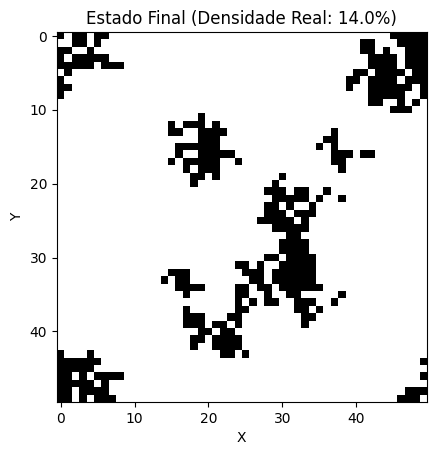

In [12]:

# Teste final
NUM_FORMIGAS = 30
DURACAO_SEGUNDOS = 180
LARGURA, ALTURA = 50, 50
QUANTIDADE_ITENS = 350
MAX_INTERACOES = 900000

ambiente = inicializar_ambiente(LARGURA, ALTURA, QUANTIDADE_ITENS)

# k1 define o quão sensível a formiga é à densidade
# k2 define quando a formiga acha que “já tem item suficiente aqui"
formigas = [ Ant( random.randint(0, LARGURA-1), random.randint(0, ALTURA-1), r=1, k1=0.2, k2=0.3) for _ in range(NUM_FORMIGAS) ]

print("Iniciando simulação...")
visualizar_ambiente(ambiente, titulo="Estado Inicial")

# Loop Principal
# Todas as formigas agem (ordem aleatória)
for _ in range(MAX_INTERACOES):
    random.shuffle(formigas)
    
    for ant in formigas:
        ant.move(LARGURA, ALTURA)
        ant.decidir_acao(ambiente)

# Se estiver carregando deve rodar até largar
# Deixar interagir até largar
# Loop extra: continuar até todas largarem
while any(ant.carregando for ant in formigas):
    for ant in formigas:
        if ant.carregando:
            ant.move(LARGURA, ALTURA)
            ant.decidir_acao(ambiente)


print("Simulação concluída!")
visualizar_ambiente(ambiente, titulo=f"Estado Final")